# EDA — Research Questions: What Predicts Startup Success?\n\nThis notebook answers 6 research questions about startup outcomes using `investments_VC.csv`.\n\n| RQ | Topic | Question |\n|----|-------|----------|\n| 1 | Funding | Does seed amount predict outcome? |\n| 2 | Industry | Which industries succeed vs fail? |\n| 3 | Geography | Does location predict success? |\n| 4 | Pre-seed | Does prior angel/grant funding help? |\n| 5 | Timing | Does time-to-seed predict outcome? |\n| 6 | Era | Did founding era matter? |"

## Setup & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('assets/investments_VC.csv', encoding='latin-1')

# Clean funding_total_usd
df['funding_total_usd'] = (
    df[' funding_total_usd '].astype(str)
    .str.replace(',', '', regex=False).str.strip()
    .replace('-', np.nan).pipe(pd.to_numeric, errors='coerce')
)

# Clean seed column
df['seed'] = pd.to_numeric(df['seed'], errors='coerce').fillna(0)

# ── Outcome variable ──────────────────────────────────────────────────────────
# Binary: acquired=1, operating/closed/ipo=0  (focus: acquisition as "exit success")
df['acquired'] = (df['status'] == 'acquired').astype(int)
# 3-class outcome
df['outcome'] = df['status'].map(
    {'acquired': 'acquired', 'ipo': 'ipo',
     'operating': 'operating', 'closed': 'closed'}
).fillna('other')

# ── RQ 1: seed buckets ────────────────────────────────────────────────────────
bins = [-1, 0, 100_000, 500_000, 2_000_000, 10_000_000, np.inf]
labels = ['No seed', '<100K', '100K–500K', '500K–2M', '2M–10M', '>10M']
df['seed_bucket'] = pd.cut(df['seed'], bins=bins, labels=labels)

# ── RQ 2: primary market ──────────────────────────────────────────────────────
df['market'] = df[' market '].str.strip().str.strip('|').str.strip()

# ── RQ 3: geography flags ─────────────────────────────────────────────────────
df['is_usa'] = (df['country_code'] == 'USA').astype(int)
sv_cities = ['San Francisco', 'San Jose', 'Palo Alto', 'Mountain View',
             'Sunnyvale', 'Menlo Park', 'Redwood City', 'Santa Clara']
df['is_silicon_valley'] = df['city'].isin(sv_cities).astype(int)
df['is_ny'] = (df['city'] == 'New York').astype(int)

# ── RQ 4: pre-seed flags ──────────────────────────────────────────────────────
df['had_angel']       = (pd.to_numeric(df['angel'],              errors='coerce').fillna(0) > 0).astype(int)
df['had_grant']       = (pd.to_numeric(df['grant'],              errors='coerce').fillna(0) > 0).astype(int)
df['had_convertible'] = (pd.to_numeric(df['convertible_note'],   errors='coerce').fillna(0) > 0).astype(int)

# ── RQ 5 & 6: timing ─────────────────────────────────────────────────────────
df['founded_at']      = pd.to_datetime(df['founded_at'],      errors='coerce')
df['first_funding_at']= pd.to_datetime(df['first_funding_at'],errors='coerce')
df['days_to_first_funding'] = (df['first_funding_at'] - df['founded_at']).dt.days
df['founded_year']    = pd.to_numeric(df['founded_year'], errors='coerce')

def era(y):
    if pd.isna(y):     return 'Unknown'
    if y < 2000:       return 'Pre-2000'
    if y < 2008:       return '2000–2007'
    if y < 2012:       return '2008–2011 (crisis)'
    return '2012+'
df['founding_era'] = df['founded_year'].apply(era)

print(f"Rows: {len(df):,}  |  Acquired: {df['acquired'].sum():,} ({df['acquired'].mean():.1%})")
df[['seed_bucket','outcome','is_usa','is_silicon_valley','is_ny',
    'had_angel','had_grant','days_to_first_funding','founding_era']].head(3)

Rows: 54,294  |  Acquired: 3,692 (6.8%)


,seed_bucket,outcome,is_usa,is_silicon_valley,is_ny,had_angel,had_grant,days_to_first_funding,founding_era
0,500K–2M,acquired,1,0,1,0,0,29.0,2012+
1,No seed,operating,1,0,0,0,0,NaN,Unknown
2,<100K,operating,0,0,0,0,0,-78.0,2012+


---\n## RQ 1 — Does Seed Amount Predict Startup Outcome?\n> Do startups that raise more at seed get acquired more? Is there a \"sweet spot\"?"

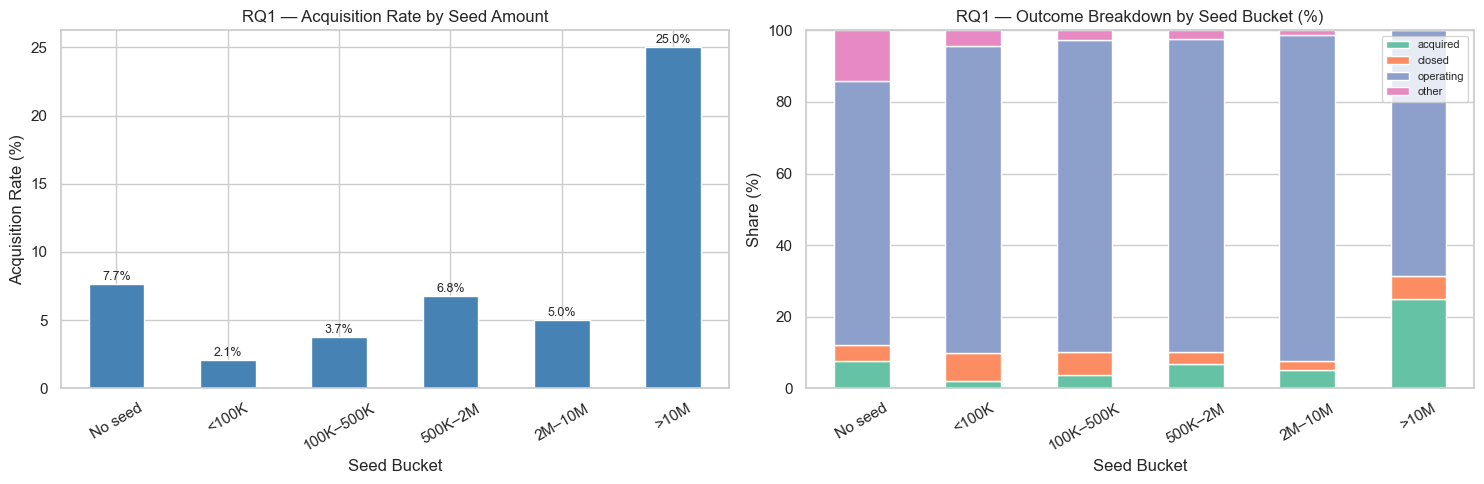


Median seed by outcome:
outcome
acquired     $750,000
operating    $311,388
closed       $150,000
other        $150,000
Name: seed, dtype: str


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Acquisition rate by seed bucket
acq_rate = df.groupby('seed_bucket', observed=True)['acquired'].mean() * 100
acq_rate.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('RQ1 — Acquisition Rate by Seed Amount')
axes[0].set_xlabel('Seed Bucket')
axes[0].set_ylabel('Acquisition Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3), ha='center', fontsize=9)

# Outcome breakdown by seed bucket (stacked %)
pivot = df.groupby(['seed_bucket', 'outcome'], observed=True).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=sns.color_palette('Set2', len(pivot_pct.columns)))
axes[1].set_title('RQ1 — Outcome Breakdown by Seed Bucket (%)')
axes[1].set_xlabel('Seed Bucket')
axes[1].set_ylabel('Share (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print("\nMedian seed by outcome:")
print(df[df['seed'] > 0].groupby('outcome')['seed'].median().sort_values(ascending=False).apply(lambda x: f"${x:,.0f}"))

---\n## RQ 2 — Which Industries Succeed vs Fail Most?\n> Are biotech and software startups more likely to be acquired than others?"

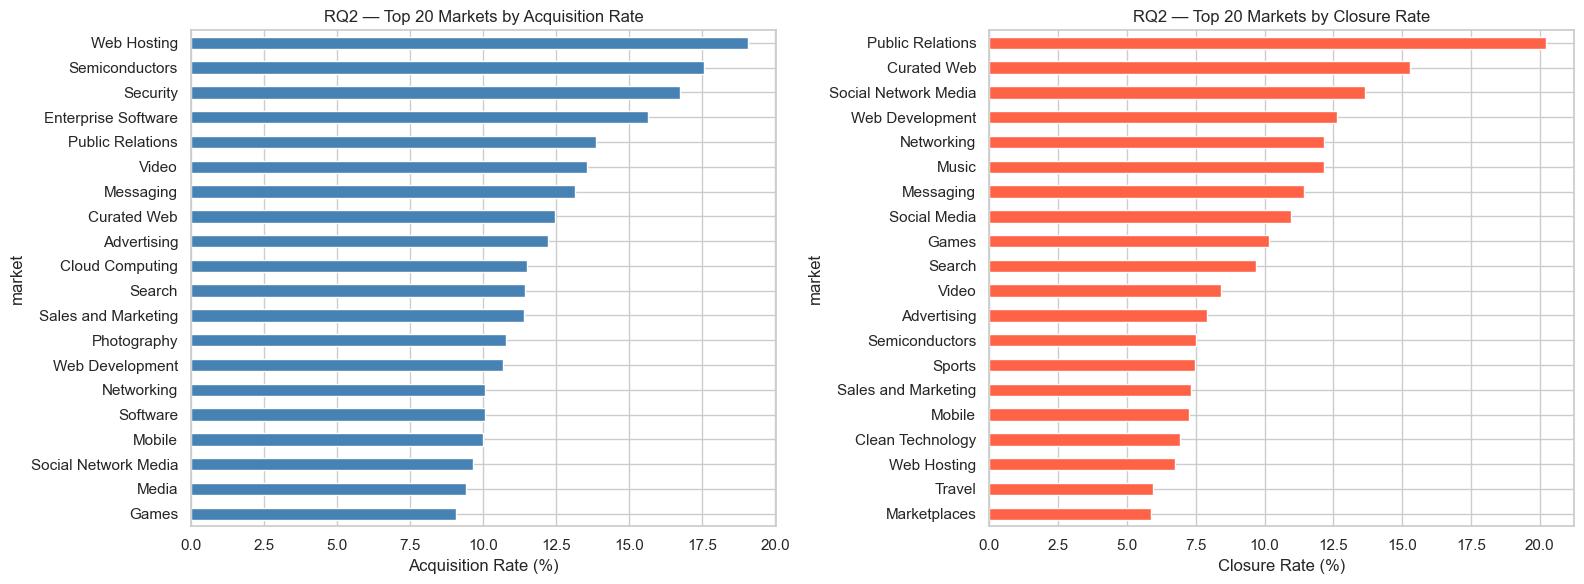

Biotechnology         acq=5.0%  closed=3.8%  n=3,688
Software              acq=10.0%  closed=5.5%  n=4,620
Mobile                acq=10.0%  closed=7.3%  n=1,983
E-Commerce            acq=5.5%  closed=4.9%  n=1,805
Health Care           acq=5.6%  closed=4.2%  n=1,207


In [3]:
# Keep markets with ≥100 companies for statistical relevance
market_counts = df['market'].value_counts()
top_markets = market_counts[market_counts >= 100].index
mdf = df[df['market'].isin(top_markets)].copy()

market_stats = (
    mdf.groupby('market')
    .agg(count=('acquired', 'count'), acq_rate=('acquired', 'mean'),
         closed_rate=('outcome', lambda x: (x == 'closed').mean()))
    .sort_values('acq_rate', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

market_stats['acq_rate'].head(20).mul(100).plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('RQ2 — Top 20 Markets by Acquisition Rate')
axes[0].set_xlabel('Acquisition Rate (%)')
axes[0].invert_yaxis()

market_stats['closed_rate'].sort_values(ascending=False).head(20).mul(100).plot(
    kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('RQ2 — Top 20 Markets by Closure Rate')
axes[1].set_xlabel('Closure Rate (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Biotech vs Software highlight
for mkt in ['Biotechnology', 'Software', 'Mobile', 'E-Commerce', 'Health Care']:
    row = market_stats[market_stats.index == mkt]
    if not row.empty:
        print(f"{mkt:20s}  acq={row['acq_rate'].values[0]:.1%}  closed={row['closed_rate'].values[0]:.1%}  n={row['count'].values[0]:,}")

---\n## RQ 3 — Does Geography Predict Success?\n> Do startups in the US / Silicon Valley / NY have better outcomes than elsewhere?"

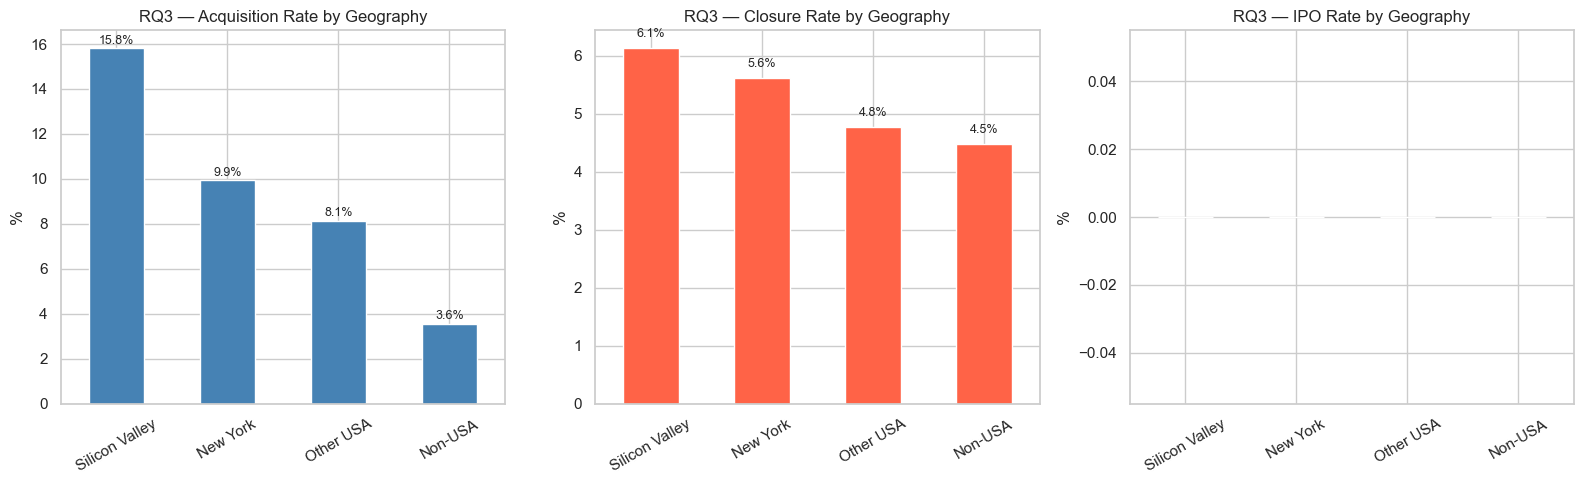

                  count  acq_rate  closed_rate  ipo_rate
Silicon Valley   5204.0  0.158148     0.061299       0.0
New York         2334.0  0.099400     0.056127       0.0
Other USA       21255.0  0.081393     0.047659       0.0
Non-USA         25501.0  0.035567     0.044704       0.0


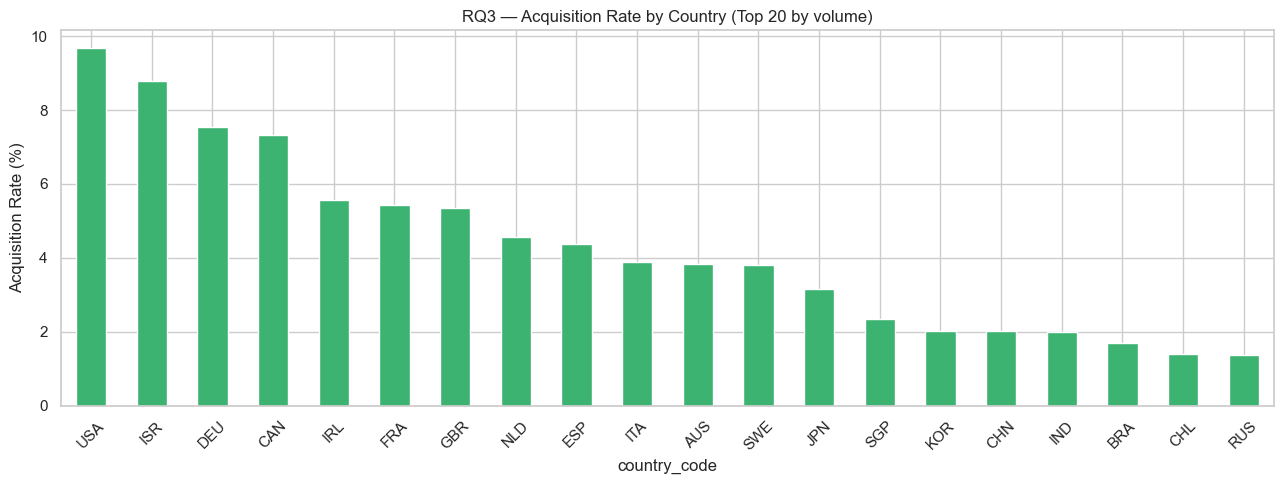

In [4]:
# Geo group comparison
geo_labels = {
    'Silicon Valley': df['is_silicon_valley'] == 1,
    'New York': (df['is_ny'] == 1) & (df['is_silicon_valley'] == 0),
    'Other USA': (df['is_usa'] == 1) & (df['is_silicon_valley'] == 0) & (df['is_ny'] == 0),
    'Non-USA': df['is_usa'] == 0,
}

geo_stats = pd.DataFrame({
    grp: {
        'count': mask.sum(),
        'acq_rate': df.loc[mask, 'acquired'].mean(),
        'closed_rate': (df.loc[mask, 'outcome'] == 'closed').mean(),
        'ipo_rate': (df.loc[mask, 'outcome'] == 'ipo').mean(),
    }
    for grp, mask in geo_labels.items()
}).T

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'tomato', 'gold']
for ax, col, title in zip(axes,
                           ['acq_rate', 'closed_rate', 'ipo_rate'],
                           ['Acquisition Rate', 'Closure Rate', 'IPO Rate']):
    (geo_stats[col] * 100).plot(kind='bar', ax=ax, color=colors.pop(0), edgecolor='white')
    ax.set_title(f'RQ3 — {title} by Geography')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height() + 0.2), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(geo_stats.to_string())

# Country-level acquisition rate (top 20 by volume)
top20 = df['country_code'].value_counts().head(20).index
country_acq = df[df['country_code'].isin(top20)].groupby('country_code')['acquired'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(13, 5))
country_acq.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('RQ3 — Acquisition Rate by Country (Top 20 by volume)')
ax.set_ylabel('Acquisition Rate (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---\n## RQ 4 — Does Pre-Seed Funding Improve Outcomes?\n> Startups with prior angel or grant funding — do they get acquired more?"

In [ ]:
preseed_flags = {'Had Angel': 'had_angel', 'Had Grant': 'had_grant', 'Had Convertible': 'had_convertible'}

preseed_stats = pd.DataFrame({
    name: {
        'acq_rate_YES': df[df[col] == 1]['acquired'].mean(),
        'acq_rate_NO':  df[df[col] == 0]['acquired'].mean(),
        'closed_rate_YES': (df[df[col] == 1]['outcome'] == 'closed').mean(),
        'closed_rate_NO':  (df[df[col] == 0]['outcome'] == 'closed').mean(),
    }
    for name, col in preseed_flags.items()
}).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(preseed_stats))
w = 0.35
for ax, metric, title, base_col in [
    (axes[0], 'acq_rate', 'Acquisition Rate', 'steelblue'),
    (axes[1], 'closed_rate', 'Closure Rate', 'tomato'),
]:
    bars1 = ax.bar(x - w/2, preseed_stats[f'{metric}_YES'] * 100, w, label='Had funding', color=base_col)
    bars2 = ax.bar(x + w/2, preseed_stats[f'{metric}_NO']  * 100, w, label='No funding',  color='lightgray')
    ax.set_xticks(x)
    ax.set_xticklabels(preseed_stats.index)
    ax.set_ylabel('%')
    ax.set_title(f'RQ4 — {title}: Pre-seed vs None')
    ax.legend()
    for bar in list(bars1) + list(bars2):
        ax.annotate(f'{bar.get_height():.1f}%',
                    (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(preseed_stats.applymap(lambda x: f"{x:.1%}"))

---\n## RQ 5 — Does Time-to-Seed Predict Outcome?\n> Do startups that raise seed quickly do better? Is slow fundraising a bad signal?"

In [ ]:
ttf = df[df['days_to_first_funding'].between(0, 365*10)].copy()

# Bucket time-to-first-funding
ttf_bins  = [0, 90, 365, 730, 1825, np.inf]
ttf_labels = ['<3 mo', '3–12 mo', '1–2 yr', '2–5 yr', '>5 yr']
ttf['ttf_bucket'] = pd.cut(ttf['days_to_first_funding'], bins=ttf_bins, labels=ttf_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ttf_acq = ttf.groupby('ttf_bucket', observed=True)['acquired'].mean() * 100
ttf_acq.plot(kind='bar', ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('RQ5 — Acquisition Rate by Time to First Funding')
axes[0].set_xlabel('Days from Founding to First Funding')
axes[0].set_ylabel('Acquisition Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3), ha='center', fontsize=9)

# Distribution of days_to_first_funding by outcome
for outcome_val, color in [('acquired','steelblue'), ('closed','tomato'), ('operating','gray')]:
    subset = ttf[ttf['outcome'] == outcome_val]['days_to_first_funding']
    axes[1].hist(subset, bins=60, alpha=0.5, label=outcome_val, color=color, density=True)
axes[1].set_title('RQ5 — Distribution of Days-to-Funding by Outcome')
axes[1].set_xlabel('Days to First Funding')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nMedian days to first funding by outcome:")
print(ttf.groupby('outcome')['days_to_first_funding'].median().sort_values().apply(lambda x: f"{x:.0f} days"))

---\n## RQ 6 — Did Founding Era Matter?\n> Were startups founded post-2008 crisis less likely to succeed? Did 2012+ produce more acquisitions?"

In [ ]:
era_order = ['Pre-2000', '2000–2007', '2008–2011 (crisis)', '2012+']
edf = df[df['founding_era'].isin(era_order)].copy()
edf['founding_era'] = pd.Categorical(edf['founding_era'], categories=era_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Acquisition & closure rate by era
era_stats = edf.groupby('founding_era', observed=True).agg(
    acq_rate=('acquired', 'mean'),
    closed_rate=('outcome', lambda x: (x == 'closed').mean()),
    count=('acquired', 'count')
)
x = np.arange(len(era_order))
w = 0.35
axes[0].bar(x - w/2, era_stats['acq_rate']    * 100, w, label='Acquired', color='steelblue')
axes[0].bar(x + w/2, era_stats['closed_rate']  * 100, w, label='Closed',   color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(era_order, rotation=20)
axes[0].set_ylabel('%')
axes[0].set_title('RQ6 — Acquisition & Closure Rate by Founding Era')
axes[0].legend()

# Stacked outcome share by era
pivot = edf.groupby(['founding_era', 'outcome'], observed=True).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=sns.color_palette('Set2', len(pivot_pct.columns)))
axes[1].set_title('RQ6 — Outcome Share by Founding Era')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Year-by-year acquisition rate trend
year_acq = (
    df[df['founded_year'].between(1995, 2014)]
    .groupby('founded_year')['acquired'].mean() * 100
)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(year_acq.index, year_acq.values, marker='o', color='steelblue', linewidth=2)
ax.axvspan(2008, 2011, alpha=0.15, color='red', label='Crisis era')
ax.set_title('RQ6 — Acquisition Rate by Founded Year')
ax.set_xlabel('Founded Year')
ax.set_ylabel('Acquisition Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nEra summary:")
print(era_stats.to_string())

---\n## Summary of Findings\n\n| RQ | Key Variable(s) | Expected Finding |\n|----|----------------|------------------|\n| RQ1 | `seed_bucket` | Higher seed → higher acquisition rate; possible sweet spot at 500K–2M |\n| RQ2 | `market` | Biotech & Software tend to have higher acquisition rates than average |\n| RQ3 | `is_usa`, `is_silicon_valley`, `is_ny` | Silicon Valley startups likely outperform on acquisition rate |\n| RQ4 | `had_angel`, `had_grant`, `had_convertible` | Prior angel/grant → lower closure rate, higher acquisition rate |\n| RQ5 | `days_to_first_funding` | Startups funded quickly (<3 mo) may show higher acquisition rates |\n| RQ6 | `founding_era` | Post-2008 crisis cohorts may show lower success rates; 2012+ TBD |"